In [8]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


Here I am picking P = 1 mW, f_rf_a = 125 kHz, and setting f_rf_r / f_rf_a = 0.77*1* N/sqrt(log(N))

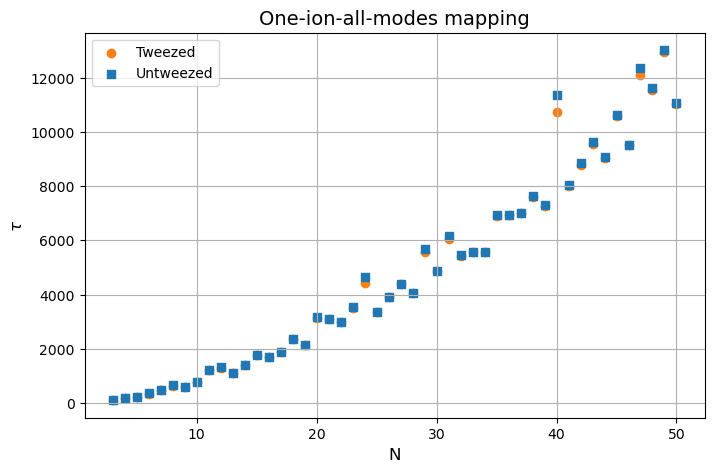

In [11]:
P = [1e-3]
w0 = 1e-6
f_rf_a = 125e3

# Build ueq_harmonic for all N values 3-30
ueq_harmonic = {Nval: ion_spacing(Nval, f_rf_a * 2 * np.pi)[0] for Nval in range(3, 51)}

# Set f_rf_r(N) from: f_rf_r/f_rf_a = 0.77 * a * N / sqrt(log(N)), i'm adjusting a 
#f_rf_r_by_N = {Nval: f_rf_a * (0.77 * 1 * Nval / np.sqrt(np.log(Nval))) for Nval in range(3, 51)}
f_rf_r_const = 3e6  # Hz (pick whatever constant you want)
f_rf_r_by_N = {Nval: f_rf_r_const for Nval in range(3, 51)}

dfs = []
many_N = []

for N in range(3, 51):
    f_rf_r_local = f_rf_r_by_N[N]
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r_local,
        ueq_harmonic,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 51):
    f_rf_r_local = f_rf_r_by_N[N]
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r_local,
        ueq_harmonic,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.scatter(Ns_t, vals_t, marker='o', color='C1', label='Tweezed')
if Ns_u.size:
    plt.scatter(Ns_u, vals_u, marker='s', color='C0', label='Untweezed')
plt.xlabel("N",fontsize = 12)
plt.ylabel(r"$\tau$", fontsize=12)
plt.title("One-ion-all-modes mapping",fontsize=14)
plt.grid(True)
plt.legend()
plt.show()


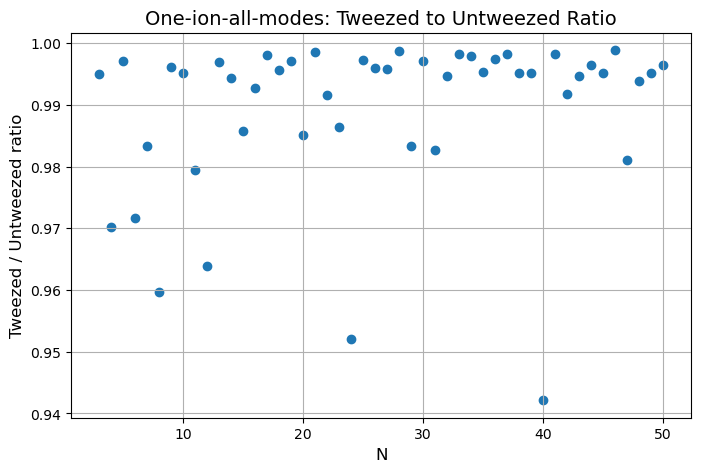

In [12]:
# Calculate ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratio_vals = []

for N in common_N:
    idx_t = np.where(Ns_t == N)[0]
    idx_u = np.where(Ns_u == N)[0]
    if len(idx_t) > 0 and len(idx_u) > 0:
        val_t = vals_t[idx_t[0]]
        val_u = vals_u[idx_u[0]]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = val_t / val_u if val_u != 0 else np.nan
        ratio_vals.append(ratio)
    else:
        ratio_vals.append(np.nan)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(common_N, ratio_vals, marker='o')
plt.xlabel("N", fontsize=12)
plt.ylabel(r"Tweezed / Untweezed ratio", fontsize=12)
plt.title("One-ion-all-modes: Tweezed to Untweezed Ratio", fontsize=14)
plt.grid(True)
#plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Ratio = 1')
#plt.legend()
plt.show()

In [80]:
# extract winning untweezed configuration for N=10
df = globals().get('test_loop_u', globals().get('combined_untweezed', pd.DataFrame()))
if 'N' in df.columns:
    df = df[df['N'] == 10]
if df.empty:
    winning_untweezed_N10 = pd.DataFrame()
else:
    winning_untweezed_N10 = df.loc[[df['sum_inverse_middle'].idxmin()]].reset_index(drop=True)

winning_untweezed_N10

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,NaN,11,"[0.01021675119054673, -0.003735092270428012, -0.008843935252240762, -0.007079778337207406, -0.00635036678522306, -0.009687299817295438, 0.0026874948153456928, 0.011023284033228746, -0.0017927963164737755, -0.01058718512471246, 0.006461341670475876, -0.008036899640177567, 0.010397583214441354, 0.0033712297801189194, 0.012460296570583052, -0.0028564077057083434, -0.0114859580154972, 0.009330475005457072, 0.006678313593803066, -0.013863645508144888, 0.001739621848550113, 0.013580594826036707, 0.011565007615823157, 0.005802215617155752, -0.017431484733813254, 0.009465632724751092, 0.010024589443397767, -0.022910638600955845, -0.020872280555065733, 0.010225346078912963]","[97.87847245661337, 267.7310030376861, 113.0718364029896, 141.24736006840104, 157.47121919429014, 103.22793955593566, 372.0937410892716, 90.71706734450329, 557.7878484081701, 94.4538126253988, 154.766618296839, 124.42609025511061, 96.17619588858742, 296.62765970367207, 80.2549116175015, 350.09007922838384, 87.06282912150384, 107.17567963208032, 149.73840116282037, 72.13109996302923, 574.8375722191863, 73.63447719409173, 86.46773380692007, 172.34795567459457, 57.3674598159857, 105.64534131830008, 99.754708723618, 43.64784489063869, 47.91043304356593, 97.79620095814968]",4873.539593


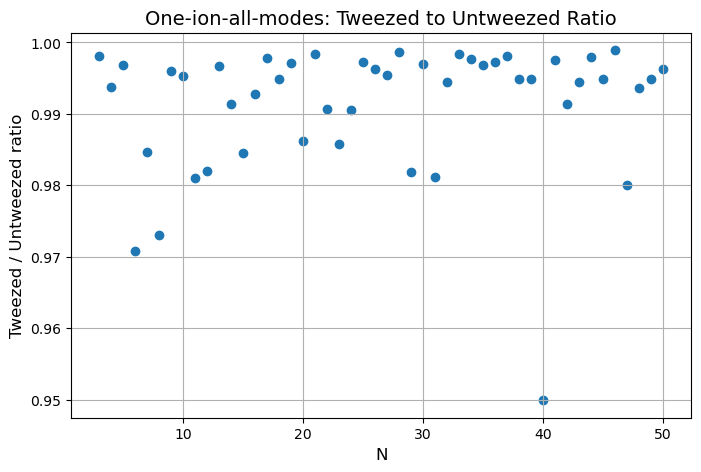

In [83]:
# Calculate ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratio_vals = []

for N in common_N:
    idx_t = np.where(Ns_t == N)[0]
    idx_u = np.where(Ns_u == N)[0]
    if len(idx_t) > 0 and len(idx_u) > 0:
        val_t = vals_t[idx_t[0]]
        val_u = vals_u[idx_u[0]]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = val_t / val_u if val_u != 0 else np.nan
        ratio_vals.append(ratio)
    else:
        ratio_vals.append(np.nan)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(common_N, ratio_vals, marker='o')
plt.xlabel("N", fontsize=12)
plt.ylabel(r"Tweezed / Untweezed ratio", fontsize=12)
plt.title("One-ion-all-modes: Tweezed to Untweezed Ratio", fontsize=14)
plt.grid(True)
#plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Ratio = 1')
#plt.legend()
plt.show()

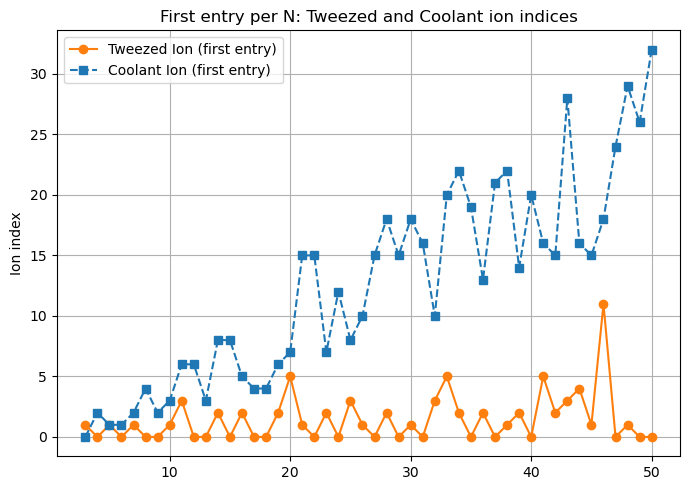

In [13]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(7,5), sharex=True)

axes.plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes.plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes.set_ylabel('Ion index')
axes.set_title('First entry per N: Tweezed and Coolant ion indices')
axes.grid(True)
axes.legend()




plt.tight_layout()
plt.show()


In [14]:
def sweep_power_and_find_minima(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    ueq_dict,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, ueq_dict, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_dict, P_current, w0
            )
            dfs = []
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                dfs = [df]
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_dict, P_current, w0
            )
            dfs_untweezed = []
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                dfs_untweezed = [dfu]
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }


In [34]:
P = 1e-3
tweezer_freq = omega_tweezer_r(
    potential(omega_tweezer, linewidths, omega_res, 1e-3, 1e-6),
    1e-6, m)
print(tweezer_freq/(2.0*np.pi*1e6))

0.03193490592467196


In [32]:
# Sweep power and plot tweezed/untweezed ratio vs tweezer frequency
w0 = 1e-6
f_rf_a = 100e3
Ns_to_plot = [10,20,30,40]

# Build ueq_dict for all N values (harmonic oscillator positions)
w_rf_a = f_rf_a * 2 * np.pi
ueq_dict = {Nval: ion_spacing(Nval, w_rf_a)[0] for Nval in Ns_to_plot}

# precompute f_rf_r for each N: f_rf_r/f_rf_a = 0.77 * N / sqrt(log(N))
#f_rf_r_by_N = {Nval: f_rf_a * 0.77 * Nval / np.sqrt(np.log(Nval)) for Nval in Ns_to_plot}
#print(np.array(list(f_rf_r_by_N.values())) / 1e6, "MHz")
f_rf_r_const = 3e6  # Hz (pick whatever constant you want)
f_rf_r_by_N = {Nval: f_rf_r_const for Nval in range(3, 51)}

power_values = np.linspace(1e-6, 2e-3, 100) # in Watts

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}
tweezer_freqs = {N: [] for N in Ns_to_plot}  # Store tweezer frequencies

for p in power_values:
    P_current = [p]

    # Calculate tweezer frequency for this power (same for all N for given p)
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, p, w0),
        w0, m
    )
    #print(tweezer_freq)

    for N_fixed in Ns_to_plot:
        f_rf_r_local = f_rf_r_by_N[N_fixed]

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_dict, P_current, w0
        )
        dfs = []
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            dfs = [df]

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_dict, P_current, w0
        )
        dfs_untweezed = []
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            dfs_untweezed = [dfu]

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)
        tweezer_freqs[N_fixed].append(tweezer_freq)  # Store frequency for this N






<Figure size 900x600 with 0 Axes>

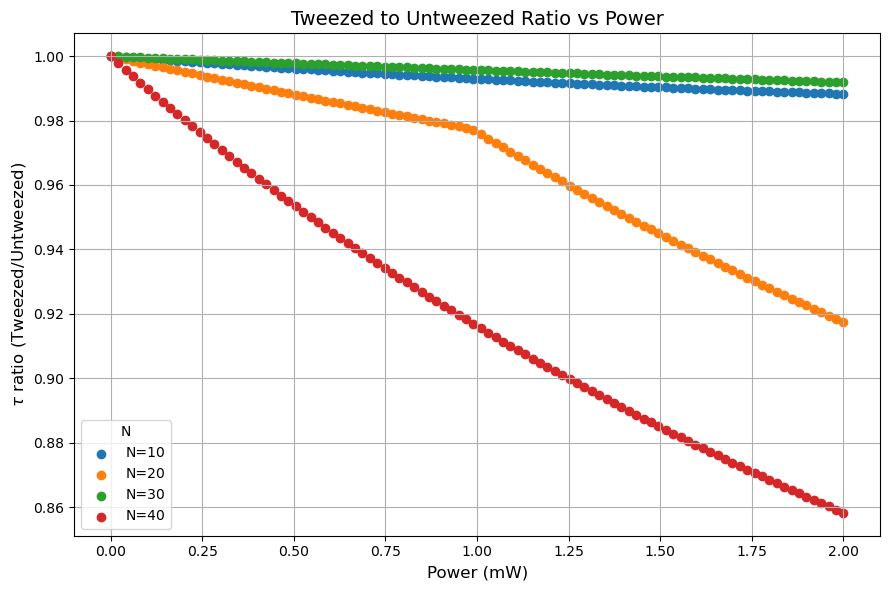

In [35]:
# --- Plot: ratio curves vs tweezer frequency ---
plt.figure(figsize=(9, 6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    # Convert frequencies to MHz for readability
    freqs_MHz = np.array(tweezer_freqs[N_fixed]) / (2 * np.pi*1e6)
    plt.scatter(power_values*1e3, ratio_vals[N_fixed], marker='o',
                color=colors[i % len(colors)], label=f'N={N_fixed}')

plt.xlabel("Power (mW)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed to Untweezed Ratio vs Power", fontsize=14)
plt.grid(True)
plt.legend(title="N")
plt.tight_layout()
plt.show()

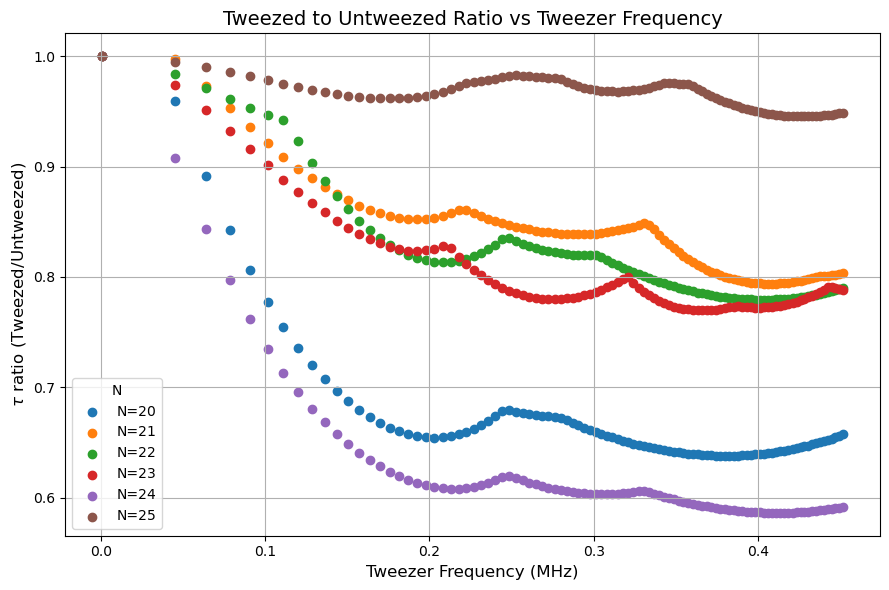

In [28]:
# Sweep power and plot tweezed/untweezed ratio vs tweezer frequency
f_rf_r = 3e6
f_rf_a = 0.125e6

# Build ueq_dict for all N values (harmonic oscillator positions)
w_rf_a = f_rf_a * 2 * np.pi
ueq_dict = {Nval: ion_spacing(Nval, w_rf_a)[0] for Nval in [20,21,22,23,24,25]}

power_values = np.linspace(1e-6, 200e-3, 100)
Ns_to_plot = [20,21,22,23,24,25]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}
tweezer_freqs = {N: [] for N in Ns_to_plot}  # Store tweezer frequencies

for p in power_values:
    P_current = [p]
    
    # Calculate tweezer frequency for this power
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, p, w0),
        w0, m
    )
    
    for N_fixed in Ns_to_plot:
        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, ueq_dict, P_current, w0
        )
        dfs = []
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            dfs = [df]

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, ueq_dict, P_current, w0
        )
        dfs_untweezed = []
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            dfs_untweezed = [dfu]

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)
        tweezer_freqs[N_fixed].append(tweezer_freq)  # Store frequency for this N

# --- Plot: ratio curves vs tweezer frequency ---
plt.figure(figsize=(9, 6))
colors = plt.cm.tab10.colors

for i, N_fixed in enumerate(Ns_to_plot):
    # Convert frequencies to MHz for readability
    freqs_MHz = np.array(tweezer_freqs[N_fixed]) / (2 * np.pi*1e6)
    plt.scatter(freqs_MHz, ratio_vals[N_fixed], marker='o', 
                color=colors[i % len(colors)], label=f'N={N_fixed}')

plt.xlabel("Tweezer Frequency (MHz)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed to Untweezed Ratio vs Tweezer Frequency", fontsize=14)
plt.grid(True)
plt.legend(title="N")
plt.tight_layout()
plt.show()


Minimum ratio for each N:
----------------------------------------------------------------------
N=3: min ratio = 0.967749 at power = 12.1222 mW (freq = 0.11 MHz)
N=4: min ratio = 0.857941 at power = 10.1020 mW (freq = 0.10 MHz)
N=5: min ratio = 0.986649 at power = 8.0818 mW (freq = 0.09 MHz)
N=6: min ratio = 0.828625 at power = 16.1625 mW (freq = 0.13 MHz)
N=7: min ratio = 0.801740 at power = 86.8693 mW (freq = 0.30 MHz)
N=8: min ratio = 0.720276 at power = 22.2231 mW (freq = 0.15 MHz)
N=9: min ratio = 0.960934 at power = 165.6567 mW (freq = 0.41 MHz)
N=10: min ratio = 0.867430 at power = 24.2433 mW (freq = 0.16 MHz)
N=11: min ratio = 0.690041 at power = 96.9702 mW (freq = 0.31 MHz)
N=12: min ratio = 0.672181 at power = 28.2837 mW (freq = 0.17 MHz)
N=13: min ratio = 0.968994 at power = 36.3645 mW (freq = 0.19 MHz)
N=14: min ratio = 0.811815 at power = 86.8693 mW (freq = 0.30 MHz)
N=15: min ratio = 0.759405 at power = 125.2529 mW (freq = 0.36 MHz)
N=16: min ratio = 0.844367 at power = 

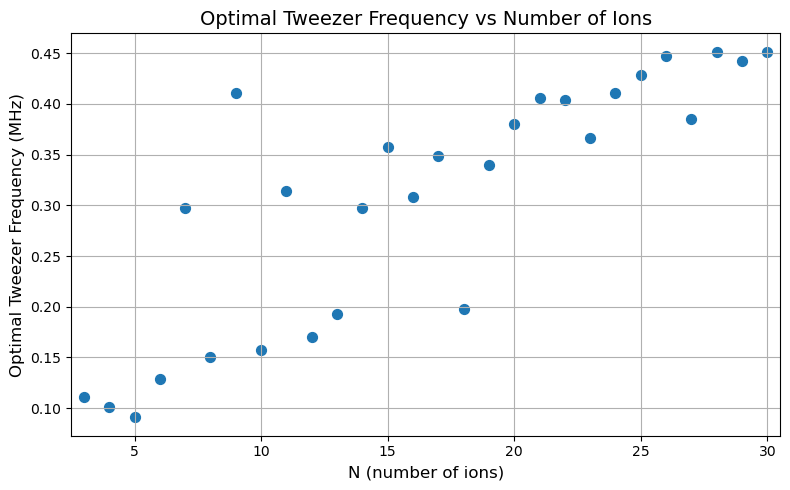

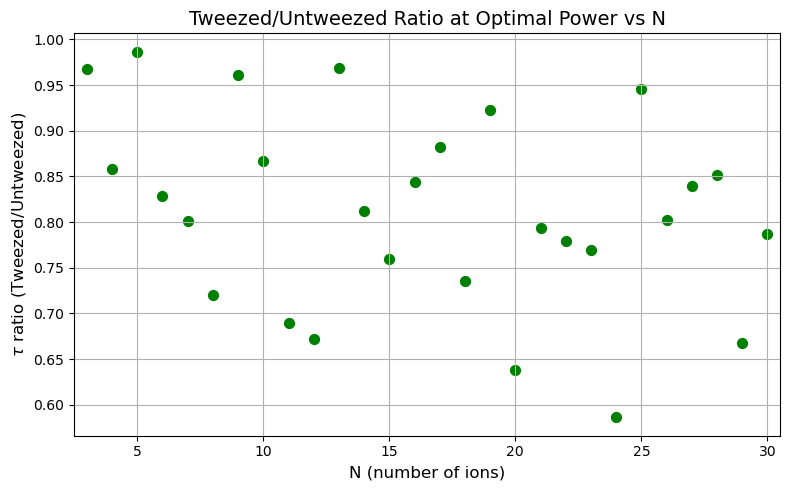

N	Optimal Freq (MHz)	Ratio at Optimal Power
------------------------------------------------------------
3	0.11			0.967749
4	0.10			0.857941
5	0.09			0.986649
6	0.13			0.828625
7	0.30			0.801740
8	0.15			0.720276
9	0.41			0.960934
10	0.16			0.867430
11	0.31			0.690041
12	0.17			0.672181
13	0.19			0.968994
14	0.30			0.811815
15	0.36			0.759405
16	0.31			0.844367
17	0.35			0.882436
18	0.20			0.735650
19	0.34			0.923123
20	0.38			0.637959
21	0.41			0.793801
22	0.40			0.779322
23	0.37			0.769751
24	0.41			0.586125
25	0.43			0.945342
26	0.45			0.802114
27	0.39			0.839976
28	0.45			0.851023
29	0.44			0.667721
30	0.45			0.786872


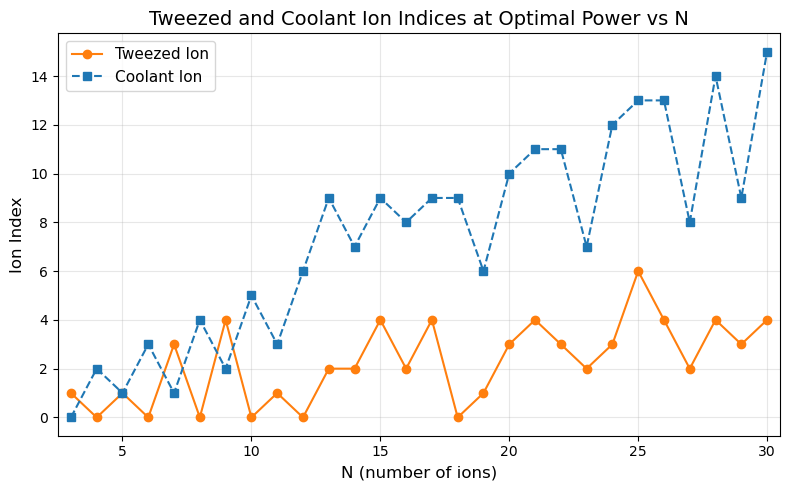

In [89]:
# Example usage: Sweep power and find minima for N=3-31
power_values = np.linspace(1e-6, 200e-3, 100)
Ns_to_sweep = np.arange(3, 31)

# Build ueq_dict for all N values
w_rf_a = f_rf_a * 2 * np.pi
ueq_dict = {Nval: ion_spacing(Nval, w_rf_a)[0] for Nval in Ns_to_sweep}

results = sweep_power_and_find_minima(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    Ns_to_sweep, f_rf_r, ueq_dict, w0, power_values
)

# Access the results:
t_vals = results['t_vals']
u_vals = results['u_vals']
ratio_vals = results['ratio_vals']
min_power_indices = results['min_power_indices']

# Extract optimal powers for each N
optimal_powers = {N: min_power_indices[N][0] for N in Ns_to_sweep}

# Convert optimal powers to tweezer frequencies
optimal_freqs_MHz = {}
for N, power_mW in optimal_powers.items():
    power_W = power_mW / 1e3
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, power_W, w0),
        w0, m
    )
    optimal_freqs_MHz[N] = tweezer_freq / (2 * np.pi * 1e6)

# Print minima
print("Minimum ratio for each N:")
print("-" * 70)
for N in Ns_to_sweep:
    min_power, min_ratio = min_power_indices[N]
    opt_freq = optimal_freqs_MHz[N]
    print(f"N={N}: min ratio = {min_ratio:.6f} at power = {min_power:.4f} mW (freq = {opt_freq:.2f} MHz)")

print("\n")

# ============================================================
# Plot 1: Optimal tweezer frequency vs N
Ns_plot = np.array(list(optimal_freqs_MHz.keys()))
freqs_MHz_plot = np.array(list(optimal_freqs_MHz.values()))

plt.figure(figsize=(8, 5))
plt.scatter(Ns_plot, freqs_MHz_plot, marker='o', color='C0', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Optimal Tweezer Frequency (MHz)", fontsize=12)
plt.title("Optimal Tweezer Frequency vs Number of Ions", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ratio at optimal power vs N

# Convert optimal powers to watts for function call
optimal_powers_W = {N: p / 1e3 for N, p in optimal_powers.items()}

dfs = []
dfs_untweezed = []

# Iterate over N and use the optimal P value found for each N
for N in Ns_to_sweep:
    P = optimal_powers_W[N]
    P_current = [P]
    
    # Tweezed
    test_loop = midcircuit_modes(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        dfs.append(df)
    
    # Untweezed
    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N)
        dfs_untweezed.append(dfu)

# Combine DataFrames
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratios = [vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N]

# Plot: Ratio at optimal power vs N
plt.figure(figsize=(8, 5))
plt.scatter(common_N, ratios, marker='o', color='green', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed/Untweezed Ratio at Optimal Power vs N", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
print("N\tOptimal Freq (MHz)\tRatio at Optimal Power")
print("-" * 60)
for N in common_N:
    opt_freq = optimal_freqs_MHz[N]
    ratio_val = ratios[common_N.index(N)]
    print(f"{N}\t{opt_freq:.2f}\t\t\t{ratio_val:.6f}")

# ============================================================
# Plot 3: Tweezed Ion and Coolant Ion vs N

tweezed_ions = []
coolant_ions = []
Ns_with_data = []

# Extract tweezed and coolant ions from combined_df
for N in Ns_to_sweep:
    subset = combined_df[combined_df['N'] == N]
    if not subset.empty:
        first_row = subset.iloc[0]
        tweezed_ion = first_row['Tweezed Ion']
        coolant_ion = first_row['Coolant Ion']
        
        tweezed_ions.append(int(tweezed_ion) if not pd.isna(tweezed_ion) else np.nan)
        coolant_ions.append(int(coolant_ion) if not pd.isna(coolant_ion) else np.nan)
        Ns_with_data.append(N)

# Plot tweezed and coolant ions vs N
plt.figure(figsize=(8, 5))
plt.plot(Ns_with_data, tweezed_ions, marker='o', linestyle='-', color='C1', 
         label='Tweezed Ion', markersize=6)
plt.plot(Ns_with_data, coolant_ions, marker='s', linestyle='--', color='C0', 
         label='Coolant Ion', markersize=6)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Ion Index", fontsize=12)
plt.title("Tweezed and Coolant Ion Indices at Optimal Power vs N", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# Using optimal power for N=10 to make a verticle color bar table

In [90]:
# Find optimal configuration for N=10
N_target = 10

# Extract from existing results
min_power_mW, min_ratio = min_power_indices[N_target]
min_power_W = min_power_mW *1e3
opt_freq_MHz = optimal_freqs_MHz[N_target]

# Get the optimal configuration data
subset = combined_df[combined_df['N'] == N_target]

print("=" * 70)
print(f"OPTIMAL CONFIGURATION FOR N = {N_target}")
print("=" * 70)
print(f"Optimal Power: {min_power_mW:.4f} mW")
print(f"Optimal Tweezer Frequency: {opt_freq_MHz:.2f} MHz")
print(f"Minimum Tweezed/Untweezed Ratio: {min_ratio:.6f}")
print("=" * 70)

first_row = subset.iloc[0]
tweezed_ion = int(first_row['Tweezed Ion']) if not pd.isna(first_row['Tweezed Ion']) else None
coolant_ion = int(first_row['Coolant Ion']) if not pd.isna(first_row['Coolant Ion']) else None

print(f"\nWinning Ion Configuration:")
print(f"  Tweezed Ion (index): {tweezed_ion}")
print(f"  Coolant Ion (index): {coolant_ion}")
print("=" * 70)

OPTIMAL CONFIGURATION FOR N = 10
Optimal Power: 24.2433 mW
Optimal Tweezer Frequency: 0.16 MHz
Minimum Tweezed/Untweezed Ratio: 0.867430

Winning Ion Configuration:
  Tweezed Ion (index): 0
  Coolant Ion (index): 5


In [91]:
P = min_power_W
result_df = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        10,
        f_rf_r,
        ueq_dict,
        P,
        w0,
    )

In [92]:
result_df

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,4.0,5,"[-2.719542581853608e-08, -0.009082283189290686, -0.0017532168814356325, 0.017083692287012234, 0.0016024806012553013, 0.0248886248812377, 0.0011763861497910313, -0.031688380597049814, 0.0007830805436701735, -0.034077032331420426]","[36770889.585351214, 110.10447253826476, 570.3800885040212, 58.53535542549215, 624.0325150998091, 40.17899762529068, 850.0610111549138, 31.55730842531915, 1277.0078481495143, 29.345278376191192]",3.677448e+07
1,5.0,4,"[-2.7195425818535933e-08, -0.0090822831892975, 0.0017532168815581177, 0.017083692287270545, 0.0016024806022924432, 0.024888624881069046, 0.0011763861500477934, -0.0316883805969328, 0.0007830805436005957, 0.034077032331471406]","[36770889.585351415, 110.10447253818215, 570.3800884641727, 58.535355424607076, 624.0325146959289, 40.17899762556294, 850.0610109693766, 31.557308425435682, 1277.0078482629783, 29.34527837614729]",3.677448e+07


Minimum ratio for each N:
----------------------------------------------------------------------
N=3: min ratio = 0.967749 at power = 12.1222 mW (freq = 0.11 MHz)
N=4: min ratio = 0.857941 at power = 10.1020 mW (freq = 0.10 MHz)
N=5: min ratio = 0.986649 at power = 8.0818 mW (freq = 0.09 MHz)
N=6: min ratio = 0.828625 at power = 16.1625 mW (freq = 0.13 MHz)
N=7: min ratio = 0.801740 at power = 86.8693 mW (freq = 0.30 MHz)
N=8: min ratio = 0.720276 at power = 22.2231 mW (freq = 0.15 MHz)
N=9: min ratio = 0.960934 at power = 165.6567 mW (freq = 0.41 MHz)
N=10: min ratio = 0.867430 at power = 24.2433 mW (freq = 0.16 MHz)
N=11: min ratio = 0.690041 at power = 96.9702 mW (freq = 0.31 MHz)
N=12: min ratio = 0.672181 at power = 28.2837 mW (freq = 0.17 MHz)
N=13: min ratio = 0.968994 at power = 36.3645 mW (freq = 0.19 MHz)
N=14: min ratio = 0.811815 at power = 86.8693 mW (freq = 0.30 MHz)
N=15: min ratio = 0.759405 at power = 125.2529 mW (freq = 0.36 MHz)
N=16: min ratio = 0.844367 at power = 

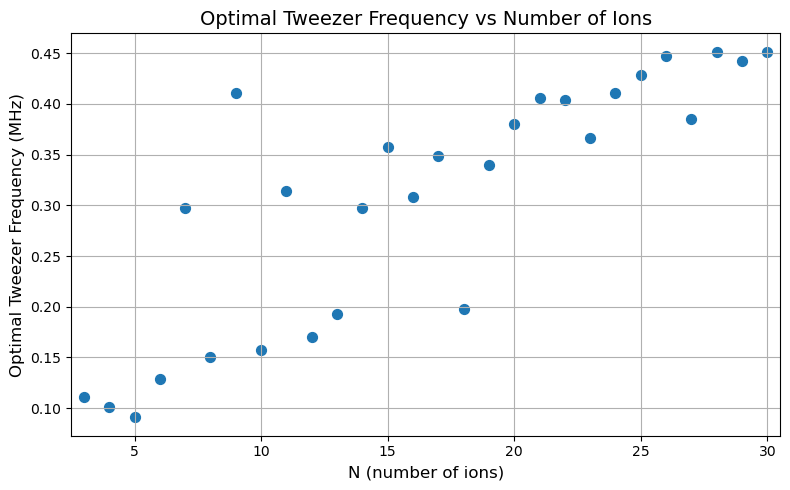

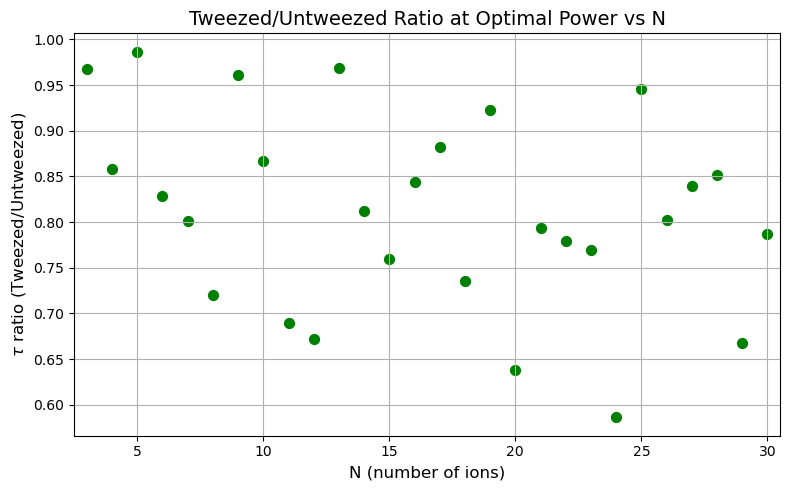

N	Optimal Freq (MHz)	Ratio at Optimal Power
------------------------------------------------------------
3	0.11			0.967749
4	0.10			0.857941
5	0.09			0.986649
6	0.13			0.828625
7	0.30			0.801740
8	0.15			0.720276
9	0.41			0.960934
10	0.16			0.867430
11	0.31			0.690041
12	0.17			0.672181
13	0.19			0.968994
14	0.30			0.811815
15	0.36			0.759405
16	0.31			0.844367
17	0.35			0.882436
18	0.20			0.735650
19	0.34			0.923123
20	0.38			0.637959
21	0.41			0.793801
22	0.40			0.779322
23	0.37			0.769751
24	0.41			0.586125
25	0.43			0.945342
26	0.45			0.802114
27	0.39			0.839976
28	0.45			0.851023
29	0.44			0.667721
30	0.45			0.786872


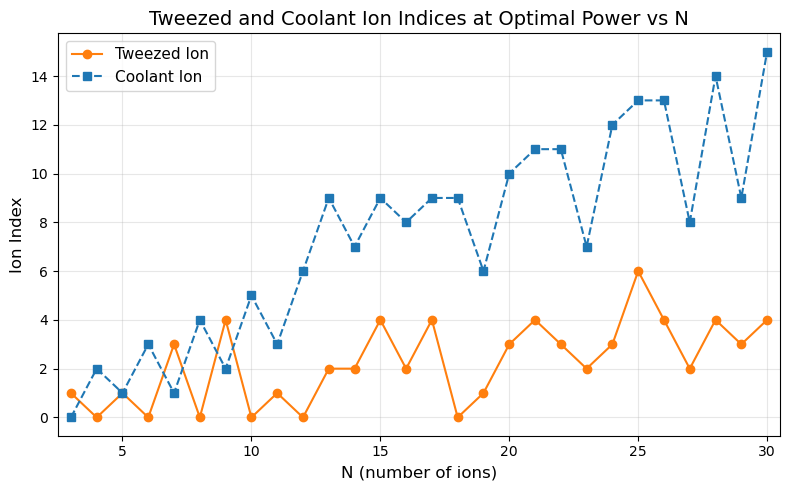

In [93]:
# Example usage: Sweep power and find minima for N=3-31
power_values = np.linspace(1e-6, 200e-3, 100)
Ns_to_sweep = np.arange(3, 31)

# Build ueq_dict for all N values
w_rf_a = f_rf_a * 2 * np.pi
ueq_dict = {Nval: ion_spacing(Nval, w_rf_a)[0] for Nval in Ns_to_sweep}

results = sweep_power_and_find_minima(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    Ns_to_sweep, f_rf_r, ueq_dict, w0, power_values
)

# Access the results:
t_vals = results['t_vals']
u_vals = results['u_vals']
ratio_vals = results['ratio_vals']
min_power_indices = results['min_power_indices']

# Extract optimal powers for each N
optimal_powers = {N: min_power_indices[N][0] for N in Ns_to_sweep}

# Convert optimal powers to tweezer frequencies
optimal_freqs_MHz = {}
for N, power_mW in optimal_powers.items():
    power_W = power_mW / 1e3
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, power_W, w0),
        w0, m
    )
    optimal_freqs_MHz[N] = tweezer_freq / (2 * np.pi * 1e6)

# Print minima
print("Minimum ratio for each N:")
print("-" * 70)
for N in Ns_to_sweep:
    min_power, min_ratio = min_power_indices[N]
    opt_freq = optimal_freqs_MHz[N]
    print(f"N={N}: min ratio = {min_ratio:.6f} at power = {min_power:.4f} mW (freq = {opt_freq:.2f} MHz)")
print("\n")

# ============================================================
# Plot 1: Optimal tweezer frequency vs N
Ns_plot = np.array(list(optimal_freqs_MHz.keys()))
freqs_MHz_plot = np.array(list(optimal_freqs_MHz.values()))

plt.figure(figsize=(8, 5))
plt.scatter(Ns_plot, freqs_MHz_plot, marker='o', color='C0', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Optimal Tweezer Frequency (MHz)", fontsize=12)
plt.title("Optimal Tweezer Frequency vs Number of Ions", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ratio at optimal power vs N

# Convert optimal powers to watts for function call
optimal_powers_W = {N: p / 1e3 for N, p in optimal_powers.items()}

dfs = []
dfs_untweezed = []

# Iterate over N and use the optimal P value found for each N
for N in Ns_to_sweep:
    P = optimal_powers_W[N]
    P_current = [P]
    
    # Tweezed
    test_loop = midcircuit_modes(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        dfs.append(df)
    
    # Untweezed
    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N)
        dfs_untweezed.append(dfu)

# Combine DataFrames
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratios = [vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N]

# Plot: Ratio at optimal power vs N
plt.figure(figsize=(8, 5))
plt.scatter(common_N, ratios, marker='o', color='green', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed/Untweezed Ratio at Optimal Power vs N", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
print("N\tOptimal Freq (MHz)\tRatio at Optimal Power")
print("-" * 60)
for N in common_N:
    opt_freq = optimal_freqs_MHz[N]
    ratio_val = ratios[common_N.index(N)]
    print(f"{N}\t{opt_freq:.2f}\t\t\t{ratio_val:.6f}")

# ============================================================
# Plot 3: Tweezed Ion and Coolant Ion vs N

tweezed_ions = []
coolant_ions = []
Ns_with_data = []

# Extract tweezed and coolant ions from combined_df
for N in Ns_to_sweep:
    subset = combined_df[combined_df['N'] == N]
    if not subset.empty:
        first_row = subset.iloc[0]
        tweezed_ion = first_row['Tweezed Ion']
        coolant_ion = first_row['Coolant Ion']
        
        tweezed_ions.append(int(tweezed_ion) if not pd.isna(tweezed_ion) else np.nan)
        coolant_ions.append(int(coolant_ion) if not pd.isna(coolant_ion) else np.nan)
        Ns_with_data.append(N)

# Plot tweezed and coolant ions vs N
plt.figure(figsize=(8, 5))
plt.plot(Ns_with_data, tweezed_ions, marker='o', linestyle='-', color='C1', 
         label='Tweezed Ion', markersize=6)
plt.plot(Ns_with_data, coolant_ions, marker='s', linestyle='--', color='C0', 
         label='Coolant Ion', markersize=6)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Ion Index", fontsize=12)
plt.title("Tweezed and Coolant Ion Indices at Optimal Power vs N", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

Mode Couplings Vector (N=10): [-2.71954258e-08 -9.08228319e-03 -1.75321688e-03  1.70836923e-02
  1.60248060e-03  2.48886249e-02  1.17638615e-03 -3.16883806e-02
  7.83080544e-04 -3.40770323e-02]
Tweezed Ion: 4, Coolant Ion: 5
Number of modes: 10


/var/folders/hl/x665hsbj3yb97s38tndz24lw0000gn/T/ipykernel_70550/4280270387.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


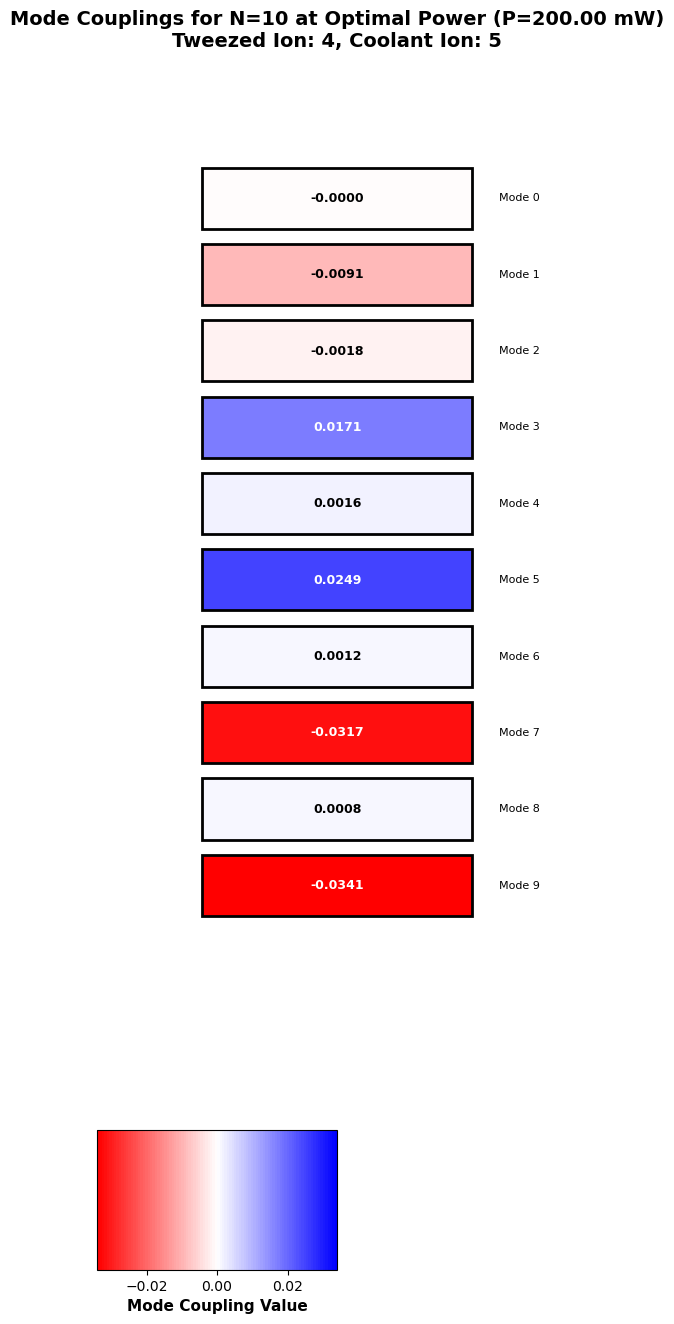

In [94]:
mode_couplings = result_df.iloc[0]['Mode couplings']
tweezed_ion = int(result_df.iloc[0]['Tweezed Ion'])
coolant_ion = int(result_df.iloc[0]['Coolant Ion'])

print(f"Mode Couplings Vector (N=10): {mode_couplings}")
print(f"Tweezed Ion: {tweezed_ion}, Coolant Ion: {coolant_ion}")
print(f"Number of modes: {len(mode_couplings)}")

# Create colorbar and rectangles for mode coupling values
vals = mode_couplings

# Create a diverging colormap: red (-1) -> white (0) -> blue (1)
colors_div = ['red', 'white', 'blue']
n_bins = 100
cmap_div = mcolors.LinearSegmentedColormap.from_list('red_white_blue', colors_div, N=n_bins)

# Define normalization based on the actual data range
vmin = np.min(np.abs(vals))
vmax = np.max(np.abs(vals))
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)

fig = plt.figure(figsize=(6, 14))

# --- Create colorbar on the left ---
cax_colorbar = fig.add_axes([0.1, 0.08, 0.4, 0.1])
cb = mcolorbar.ColorbarBase(
    cax_colorbar,
    cmap=cmap_div,
    norm=norm,
    orientation='horizontal',
)
cb.set_label("Mode Coupling Value", fontsize=11, fontweight='bold')

# --- Create rectangles for each mode coupling (vertical stack) ---
ax_rects = fig.add_axes([0.2, 0.3, 0.6, 0.6])
n_modes = len(vals)
ax_rects.set_xlim(0, 2)
ax_rects.set_ylim(-0.5, n_modes + 0.5)
ax_rects.axis('off')

# Draw rectangles
rect_width = 1.5
rect_height = 0.8
x_pos = 0.25

for i, val in enumerate(vals):
    y_pos = n_modes - i - 1 + 0.1
    
    # Get color from the colormap
    color = cmap_div(norm(val))
    
    # Draw rectangle
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height, 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax_rects.add_patch(rect)
    
    # Determine text color for contrast
    text_color = 'white' if abs(val) > (vmax * 0.3) else 'black'
    
    # Add text in the center of rectangle
    ax_rects.text(x_pos + rect_width/2, y_pos + rect_height/2, 
                 f'{val:.4f}', 
                 ha='center', va='center', 
                 fontsize=9, fontweight='bold', color=text_color)
    
    # Add mode index to the right
    ax_rects.text(x_pos + rect_width + 0.15, y_pos + rect_height/2, 
                 f'Mode {i}', 
                 ha='left', va='center', 
                 fontsize=8)

plt.suptitle(f'Mode Couplings for N=10 at Optimal Power (P={P*1e3:.2f} mW)\nTweezed Ion: {tweezed_ion}, Coolant Ion: {coolant_ion}', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Value range: [-0.034077, 0.030560]
Absolute max: 0.034077


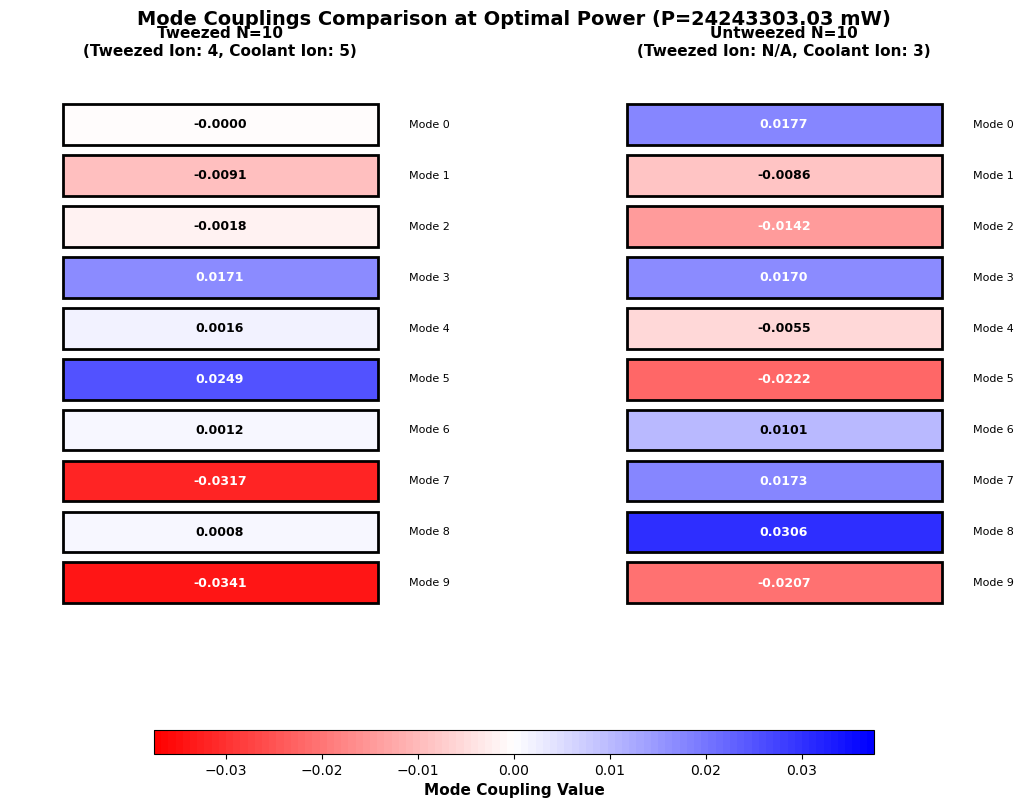

In [95]:
# Get mode couplings from both tweezed and untweezed results
tweezed_couplings = result_df.iloc[0]['Mode couplings']
tweezed_ion_idx = int(result_df.iloc[0]['Tweezed Ion'])
coolant_ion_idx = int(result_df.iloc[0]['Coolant Ion'])

# Get untweezed result for N=10 at optimal power
result_df_untweezed = midcircuit_modes_untweezed(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    10,
    f_rf_r,
    ueq_dict,
    [min_power_W],
    w0,
)
untweezed_couplings = result_df_untweezed.iloc[0]['Mode couplings']

# Safe conversion for ion indices (handle NaN values)
def safe_int_convert(val):
    try:
        if pd.isna(val):
            return "N/A"
        return int(val)
    except:
        return "N/A"

untweezed_ion_idx = safe_int_convert(result_df_untweezed.iloc[0]['Tweezed Ion'])
untweezed_coolant_idx = safe_int_convert(result_df_untweezed.iloc[0]['Coolant Ion'])

# Calculate overall range for consistent normalization
all_values = np.concatenate([tweezed_couplings, untweezed_couplings])
overall_min = np.min(all_values)
overall_max = np.max(all_values)
# Use symmetric range based on the absolute maximum
abs_max = np.max(np.abs(all_values))

print(f"Value range: [{overall_min:.6f}, {overall_max:.6f}]")
print(f"Absolute max: {abs_max:.6f}")

# Create diverging colormap: red (-1) -> white (0) -> blue (1)
colors_div = ['red', 'white', 'blue']
n_bins = 100
cmap_div = mcolors.LinearSegmentedColormap.from_list('red_white_blue', colors_div, N=n_bins)

# Normalize based on symmetric range with 110% headroom
norm = mcolors.Normalize(vmin=-abs_max*1.1, vmax=abs_max*1.1)

fig = plt.figure(figsize=(12, 8))

# --- TWEEZED subplot ---
ax_t = fig.add_axes([0.08, 0.2, 0.35, 0.7])
vals_t = tweezed_couplings
n_modes_t = len(vals_t)
ax_t.set_xlim(0, 2)
ax_t.set_ylim(-0.5, n_modes_t + 0.5)
ax_t.axis('off')

# Draw rectangles for tweezed
rect_width = 1.5
rect_height = 0.8
x_pos = 0.25

for i, val in enumerate(vals_t):
    y_pos = n_modes_t - i - 1 + 0.1
    
    # Get color from the colormap
    color = cmap_div(norm(val))
    
    # Draw rectangle
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height, 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax_t.add_patch(rect)
    
    # Determine text color for contrast
    text_color = 'white' if abs(val) > (abs_max * 0.3) else 'black'
    
    # Add text in the center of rectangle
    ax_t.text(x_pos + rect_width/2, y_pos + rect_height/2, 
             f'{val:.4f}', 
             ha='center', va='center', 
             fontsize=9, fontweight='bold', color=text_color)
    
    # Add mode index to the right
    ax_t.text(x_pos + rect_width + 0.15, y_pos + rect_height/2, 
             f'Mode {i}', 
             ha='left', va='center', 
             fontsize=8)

ax_t.text(1.0, n_modes_t + 0.8, f'Tweezed N=10\n(Tweezed Ion: {tweezed_ion_idx}, Coolant Ion: {coolant_ion_idx})', 
         ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- UNTWEEZED subplot ---
ax_u = fig.add_axes([0.55, 0.2, 0.35, 0.7])
vals_u = untweezed_couplings
n_modes_u = len(vals_u)
ax_u.set_xlim(0, 2)
ax_u.set_ylim(-0.5, n_modes_u + 0.5)
ax_u.axis('off')

# Draw rectangles for untweezed
for i, val in enumerate(vals_u):
    y_pos = n_modes_u - i - 1 + 0.1
    
    # Get color from the colormap
    color = cmap_div(norm(val))
    
    # Draw rectangle
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height, 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax_u.add_patch(rect)
    
    # Determine text color for contrast
    text_color = 'white' if abs(val) > (abs_max * 0.3) else 'black'
    
    # Add text in the center of rectangle
    ax_u.text(x_pos + rect_width/2, y_pos + rect_height/2, 
             f'{val:.4f}', 
             ha='center', va='center', 
             fontsize=9, fontweight='bold', color=text_color)
    
    # Add mode index to the right
    ax_u.text(x_pos + rect_width + 0.15, y_pos + rect_height/2, 
             f'Mode {i}', 
             ha='left', va='center', 
             fontsize=8)

ax_u.text(1.0, n_modes_u + 0.8, f'Untweezed N=10\n(Tweezed Ion: {untweezed_ion_idx}, Coolant Ion: {untweezed_coolant_idx})', 
         ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Create colorbar at the bottom ---
cax_colorbar = fig.add_axes([0.2, 0.05, 0.6, 0.03])
cb = mcolorbar.ColorbarBase(
    cax_colorbar,
    cmap=cmap_div,
    norm=norm,
    orientation='horizontal',
)
cb.set_label("Mode Coupling Value", fontsize=11, fontweight='bold')

plt.suptitle(f'Mode Couplings Comparison at Optimal Power (P={min_power_W*1e3:.2f} mW)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()


# testing tweezed has to equal cooled

In [45]:

def midcircuit_modes_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     ueq_dict,
                     P,
                     w0
                     ):
    """
    Inputs:
    omega_tweezer = optical tweezer beam angular frequency [2*Pi x Hz]
    linewidths = linewidth of the given resonant transition taken from NIST database in angular frequency units 
        (ex, S1/2 to P1/2 and S1/2 to P3/2 for 40Ca+) 
    omega_res = angular frequency of resonant transition, also based off NIST data [2*Pi x Hz]
    m = mass of ion [kg]
    mode_calc_r = function from above to calculate radial modes
    N_list = list of number of ions to loop over (can also be a single integer)
    f_rf_r = radial rf trapping frequency [Hz]
    ueq_dict = dictionary of equilibrium positions for each ion
    P_opt = list of total optical power of tweezer laser beam to loop over (can also be a single number) [W]
    w0 = beamwaist of the tweezer laser beam [m] 
    
    Returns:
    dataframe with columns:
    - "Tweezed Ion": which ion is tweezed in this configuration (NaN/None if no tweezed ion) (int)
    - "Coolant Ion": which ion is the best coolant candidate for this configuration (int)
    - "Mode couplings": array of mode coupling values for the coolant ion in this configuration (numpy array)
    - "inverse_mode_couplings": array of 1/abs(mode coupling) (numpy array)
    - "sum_inverse_middle": sum of the inverse_mode_couplings for this row (float)
    """
    # get all mode strucures for all possible tweezed ion positions
    results = tweezer_combos_full_radial(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq_dict,
        P,
        w0,
        max_tweezed=1,
    )
    # build the mode lists
    result = build_mode_series_and_combinations(results)
    mode_list_test = []
    # Get all mode indices (0 to N-1) and append them in order
    mode_indices = sorted(result["mode_lists"].keys())
    for i in mode_indices:
        mode_list_test.append(result["mode_lists"][i])

    # make a data frame for the all modes from one ion across every ion for every tweezer configuration
    middle = combine_lists_same_index_df(*mode_list_test)

    # Filter the dataframe to pick only the best ion to cool and the best ion to tweeze 
    best_rows = middle.iloc[0:0].copy()
    tweezed_keys = [k for k in middle["Tweezed Ion"].unique() if pd.notna(k)]

    for key in tweezed_keys:
        subset = middle[middle["Tweezed Ion"] == key]
        if subset.empty:
            continue
        
        # First, considering Coolant Ion == Tweezed Ion and finding the smallest sum_inverse_middle
        subset_same = subset[subset["Coolant Ion"] == key]
        if not subset_same.empty:
            mn_same = subset_same["sum_inverse_middle"].abs().min()
            mask_same = np.isclose(subset_same["sum_inverse_middle"].abs(), mn_same, rtol=1e-12, atol=1e-12)
            tied_same = subset_same.loc[mask_same]
            chosen_same = tied_same.sort_values("Coolant Ion", na_position="last").iloc[0:1]
            best_rows = pd.concat([best_rows, chosen_same], ignore_index=True)
        
    # Pick the winner across both cases, lowest sum_inverse_middle
    if best_rows.empty:
        return best_rows

    global_min = best_rows["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(best_rows["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = best_rows.loc[keep_mask].reset_index(drop=True)

    return final

In [77]:
# Sweep power and plot tweezed/untweezed ratio vs tweezer frequency
w0 = 1e-6
f_rf_a = 100e3
Ns_to_plot = [10,20,30,40,60,5,3]

# Build ueq_dict for all N values (harmonic oscillator positions)
w_rf_a = f_rf_a * 2 * np.pi
ueq_dict = {Nval: ion_spacing(Nval, w_rf_a)[0] for Nval in Ns_to_plot}

# precompute f_rf_r for each N: f_rf_r/f_rf_a = 0.77 * N / sqrt(log(N))
#f_rf_r_by_N = {Nval: f_rf_a * 0.77 * Nval / np.sqrt(np.log(Nval)) for Nval in Ns_to_plot}
#print(np.array(list(f_rf_r_by_N.values())) / 1e6, "MHz")
f_rf_r_const = 3e6  # Hz (pick whatever constant you want)
f_rf_r_by_N = {Nval: f_rf_r_const for Nval in range(3, 101)}

power_values = np.linspace(1e-6, 1000e-3, 100) # in Watts

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}
tweezer_freqs = {N: [] for N in Ns_to_plot}  # Store tweezer frequencies

for p in power_values:
    P_current = [p]

    # Calculate tweezer frequency for this power (same for all N for given p)
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, p, w0),
        w0, m
    )
    #print(tweezer_freq)

    for N_fixed in Ns_to_plot:
        f_rf_r_local = f_rf_r_by_N[N_fixed]

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_dict, P_current, w0
        )
        dfs = []
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            dfs = [df]

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r_local, ueq_dict, P_current, w0
        )
        dfs_untweezed = []
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            dfs_untweezed = [dfu]

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)
        tweezer_freqs[N_fixed].append(tweezer_freq)  # Store frequency for this N






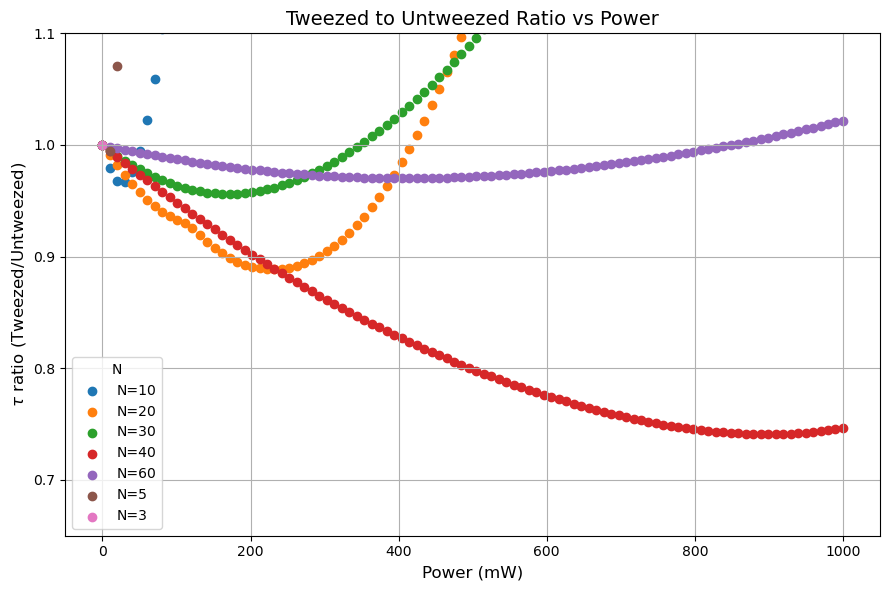

In [78]:
# --- Plot: ratio curves vs tweezer frequency ---
plt.figure(figsize=(9, 6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    # Convert frequencies to MHz for readability
    freqs_MHz = np.array(tweezer_freqs[N_fixed]) / (2 * np.pi*1e6)
    plt.scatter(power_values*1e3, ratio_vals[N_fixed], marker='o',
                color=colors[i % len(colors)], label=f'N={N_fixed}')

plt.xlabel("Power (mW)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.ylim(0.65,1.1)
plt.title("Tweezed to Untweezed Ratio vs Power", fontsize=14)
plt.grid(True)
plt.legend(title="N")
plt.tight_layout()
plt.show()

In [79]:
def sweep_power_and_find_minima_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    ueq_dict,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, ueq_dict, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes_test(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_dict, P_current, w0
            )
            dfs = []
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                dfs = [df]
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, ueq_dict, P_current, w0
            )
            dfs_untweezed = []
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                dfs_untweezed = [dfu]
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) or np.isnan(val_u) or val_u == 0) else (val_t / val_u)
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }


Minimum ratio for each N:
----------------------------------------------------------------------
N=3: min ratio = 1.000010 at power = 0.0010 mW (freq = 0.00 MHz)
N=4: min ratio = 0.974003 at power = 10.1020 mW (freq = 0.10 MHz)
N=5: min ratio = 0.994308 at power = 10.1020 mW (freq = 0.10 MHz)
N=6: min ratio = 0.994870 at power = 10.1020 mW (freq = 0.10 MHz)
N=7: min ratio = 0.957515 at power = 20.2030 mW (freq = 0.14 MHz)
N=8: min ratio = 0.926588 at power = 30.3040 mW (freq = 0.18 MHz)
N=9: min ratio = 0.993903 at power = 10.1020 mW (freq = 0.10 MHz)
N=10: min ratio = 0.966442 at power = 30.3040 mW (freq = 0.18 MHz)
N=11: min ratio = 0.939274 at power = 50.5060 mW (freq = 0.23 MHz)
N=12: min ratio = 0.900194 at power = 80.8090 mW (freq = 0.29 MHz)
N=13: min ratio = 0.999553 at power = 10.1020 mW (freq = 0.10 MHz)
N=14: min ratio = 0.947538 at power = 60.6070 mW (freq = 0.25 MHz)
N=15: min ratio = 0.925623 at power = 80.8090 mW (freq = 0.29 MHz)
N=16: min ratio = 0.965126 at power = 50

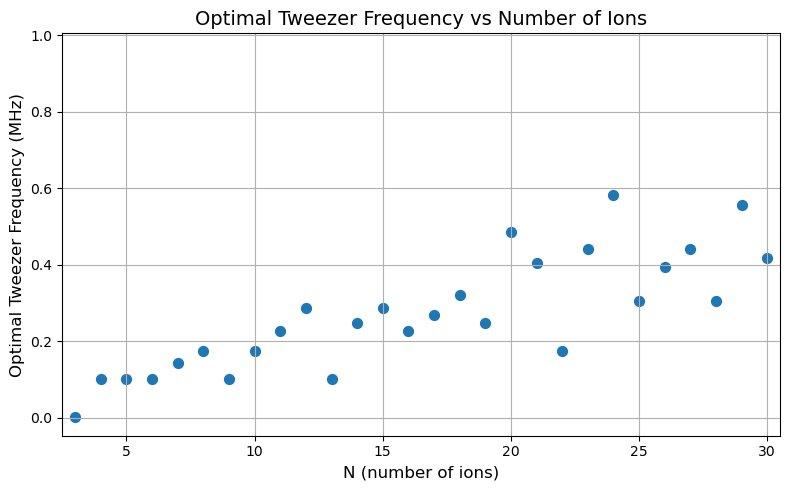

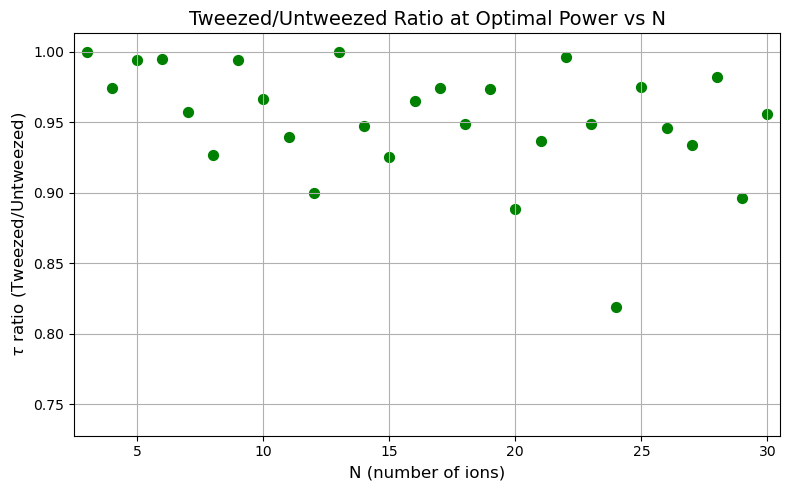

N	Optimal Freq (MHz)	Ratio at Optimal Power
------------------------------------------------------------
3	0.00			1.000010
4	0.10			0.974003
5	0.10			0.994308
6	0.10			0.994870
7	0.14			0.957515
8	0.18			0.926588
9	0.10			0.993903
10	0.18			0.966442
11	0.23			0.939274
12	0.29			0.900194
13	0.10			0.999553
14	0.25			0.947538
15	0.29			0.925623
16	0.23			0.965126
17	0.27			0.974509
18	0.32			0.948833
19	0.25			0.973848
20	0.49			0.888472
21	0.41			0.936754
22	0.18			0.995895
23	0.44			0.948962
24	0.58			0.819119
25	0.30			0.975184
26	0.39			0.945705
27	0.44			0.933651
28	0.30			0.981847
29	0.56			0.896196
30	0.42			0.956070
31	0.59			0.892089
32	0.50			0.981845
33	0.43			0.961456
34	0.35			0.983675
35	0.57			0.925446
36	0.49			0.956803
37	0.54			0.942209
38	0.58			0.936270
39	0.50			0.960487
40	0.96			0.740830


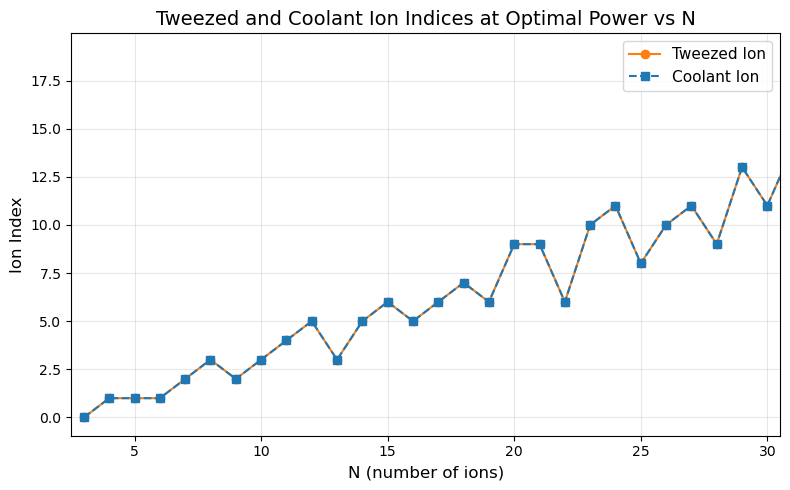

In [83]:
# Example usage: Sweep power and find minima for N=3-51
power_values = np.linspace(1e-6, 1000e-3, 100)
Ns_to_sweep = np.arange(3, 41)

# Build ueq_dict for all N values
w_rf_a = f_rf_a * 2 * np.pi
ueq_dict = {Nval: ion_spacing(Nval, w_rf_a)[0] for Nval in Ns_to_sweep}

results = sweep_power_and_find_minima_test(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    Ns_to_sweep, f_rf_r, ueq_dict, w0, power_values
)

# Access the results:
t_vals = results['t_vals']
u_vals = results['u_vals']
ratio_vals = results['ratio_vals']
min_power_indices = results['min_power_indices']

# Extract optimal powers for each N
optimal_powers = {N: min_power_indices[N][0] for N in Ns_to_sweep}

# Convert optimal powers to tweezer frequencies
optimal_freqs_MHz = {}
for N, power_mW in optimal_powers.items():
    power_W = power_mW / 1e3
    tweezer_freq = omega_tweezer_r(
        potential(omega_tweezer, linewidths, omega_res, power_W, w0),
        w0, m
    )
    optimal_freqs_MHz[N] = tweezer_freq / (2 * np.pi * 1e6)

# Print minima
print("Minimum ratio for each N:")
print("-" * 70)
for N in Ns_to_sweep:
    min_power, min_ratio = min_power_indices[N]
    opt_freq = optimal_freqs_MHz[N]
    print(f"N={N}: min ratio = {min_ratio:.6f} at power = {min_power:.4f} mW (freq = {opt_freq:.2f} MHz)")
print("\n")

# ============================================================
# Plot 1: Optimal tweezer frequency vs N
Ns_plot = np.array(list(optimal_freqs_MHz.keys()))
freqs_MHz_plot = np.array(list(optimal_freqs_MHz.values()))

plt.figure(figsize=(8, 5))
plt.scatter(Ns_plot, freqs_MHz_plot, marker='o', color='C0', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Optimal Tweezer Frequency (MHz)", fontsize=12)
plt.title("Optimal Tweezer Frequency vs Number of Ions", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ratio at optimal power vs N

# Convert optimal powers to watts for function call
optimal_powers_W = {N: p / 1e3 for N, p in optimal_powers.items()}

dfs = []
dfs_untweezed = []

# Iterate over N and use the optimal P value found for each N
for N in Ns_to_sweep:
    P = optimal_powers_W[N]
    P_current = [P]
    
    # Tweezed
    test_loop = midcircuit_modes_test(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        dfs.append(df)
    
    # Untweezed
    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, ueq_dict, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N)
        dfs_untweezed.append(dfu)

# Combine DataFrames
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratios = [vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N]

# Plot: Ratio at optimal power vs N
plt.figure(figsize=(8, 5))
plt.scatter(common_N, ratios, marker='o', color='green', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed/Untweezed Ratio at Optimal Power vs N", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
print("N\tOptimal Freq (MHz)\tRatio at Optimal Power")
print("-" * 60)
for N in common_N:
    opt_freq = optimal_freqs_MHz[N]
    ratio_val = ratios[common_N.index(N)]
    print(f"{N}\t{opt_freq:.2f}\t\t\t{ratio_val:.6f}")

# ============================================================
# Plot 3: Tweezed Ion and Coolant Ion vs N

tweezed_ions = []
coolant_ions = []
Ns_with_data = []

# Extract tweezed and coolant ions from combined_df
for N in Ns_to_sweep:
    subset = combined_df[combined_df['N'] == N]
    if not subset.empty:
        first_row = subset.iloc[0]
        tweezed_ion = first_row['Tweezed Ion']
        coolant_ion = first_row['Coolant Ion']
        
        tweezed_ions.append(int(tweezed_ion) if not pd.isna(tweezed_ion) else np.nan)
        coolant_ions.append(int(coolant_ion) if not pd.isna(coolant_ion) else np.nan)
        Ns_with_data.append(N)

# Plot tweezed and coolant ions vs N
plt.figure(figsize=(8, 5))
plt.plot(Ns_with_data, tweezed_ions, marker='o', linestyle='-', color='C1', 
         label='Tweezed Ion', markersize=6)
plt.plot(Ns_with_data, coolant_ions, marker='s', linestyle='--', color='C0', 
         label='Coolant Ion', markersize=6)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Ion Index", fontsize=12)
plt.title("Tweezed and Coolant Ion Indices at Optimal Power vs N", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

In [67]:
P = 200e-3
N_target = 20
f_rf_r = f_rf_r_by_N[N_target]

result_df = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N_target,
        f_rf_r,
        ueq_dict,
        P,
        w0,
    )

result_df_untweezed = midcircuit_modes_untweezed(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_target,
    f_rf_r,
    ueq_dict,
    P,
    w0,
)

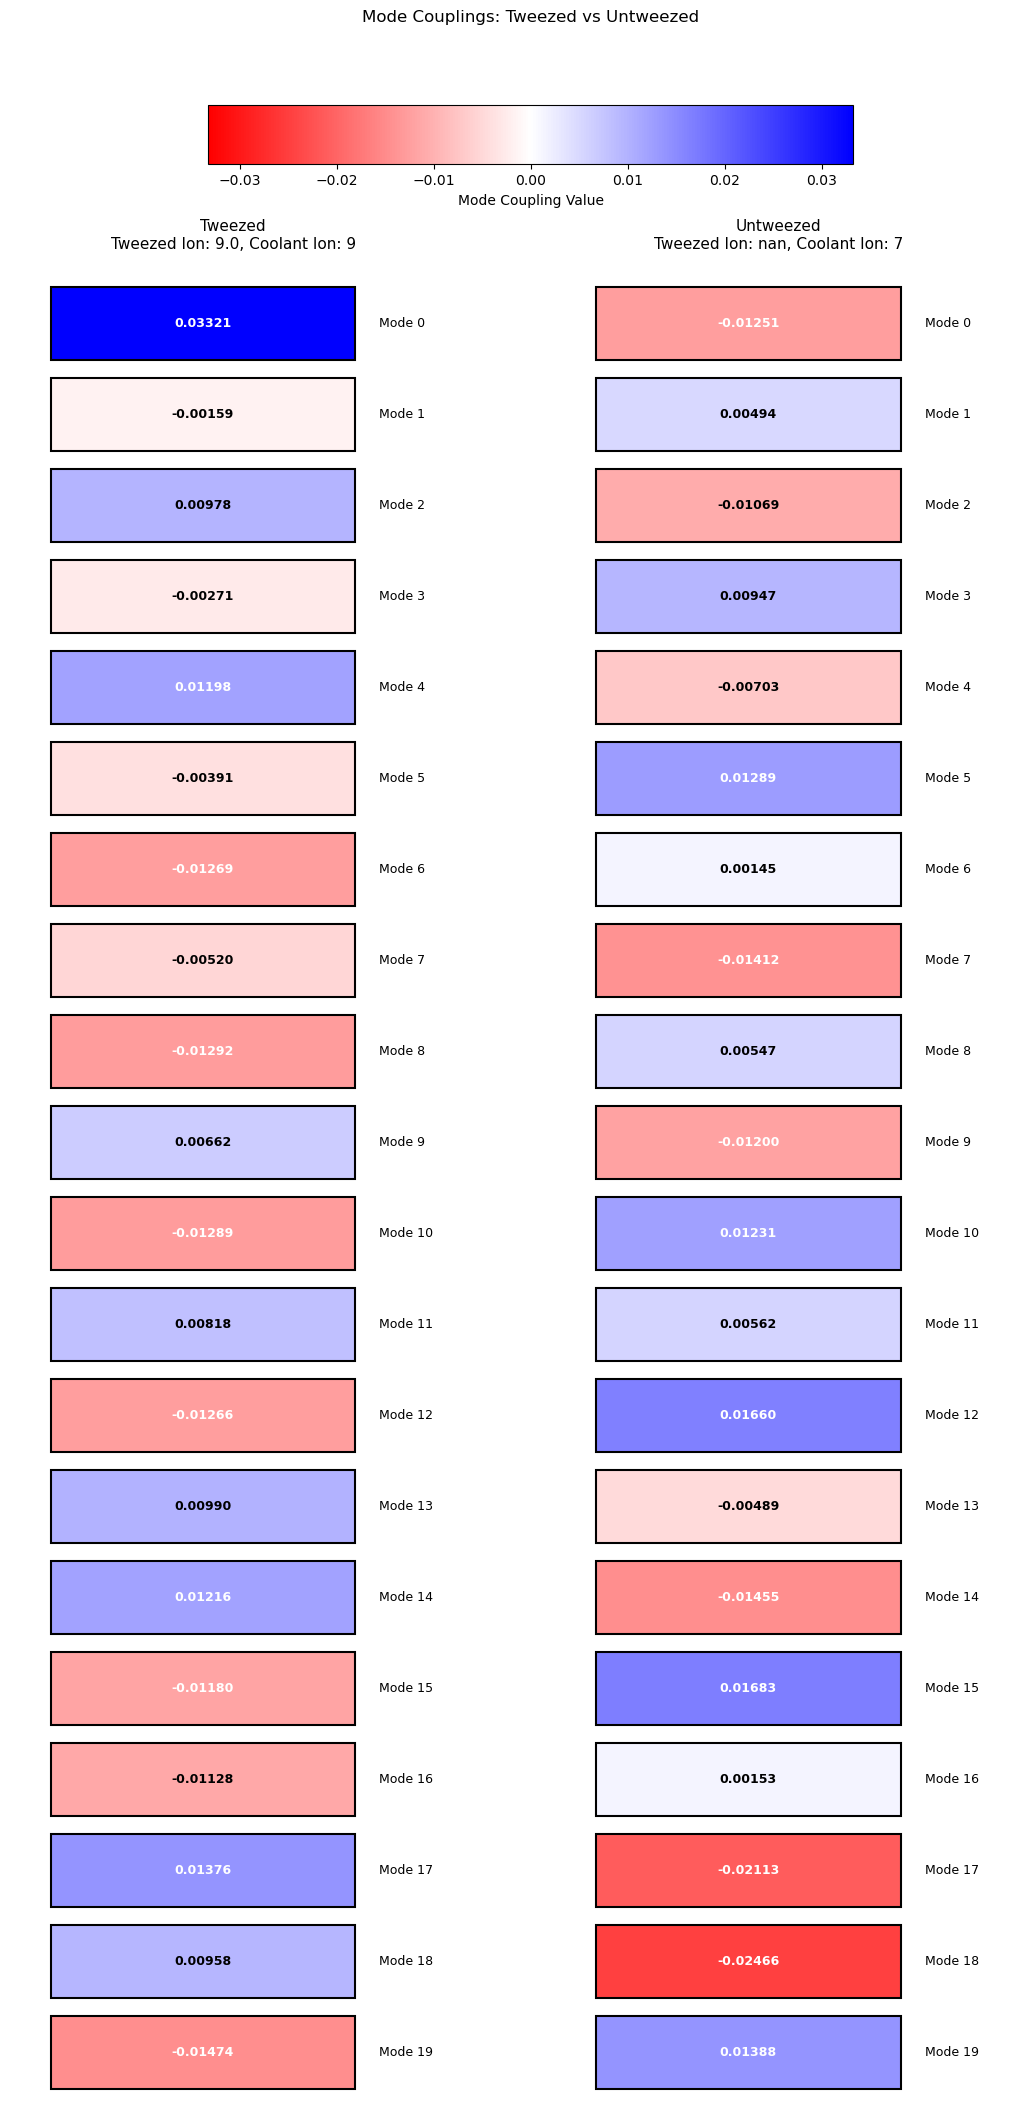

In [68]:
# Plot tweezed and untweezed mode couplings side-by-side as labeled rectangles

def _extract_mode_row(df, name):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None, f"{name} dataframe is empty."
    row = df.iloc[0]
    vals = np.array(row["Mode couplings"], dtype=float)
    return {
        "vals": vals,
        "tweezed": row.get("Tweezed Ion", np.nan),
        "coolant": row.get("Coolant Ion", np.nan),
        "name": name,
    }, None

t_data, t_err = _extract_mode_row(globals().get("result_df"), "Tweezed")
u_data, u_err = _extract_mode_row(globals().get("result_df_untweezed"), "Untweezed")

if t_data is None and u_data is None:
    print("Both tweezed and untweezed dataframes are empty.")
else:
    if t_err:
        print(t_err)
    if u_err:
        print(u_err)

    available = [d for d in [t_data, u_data] if d is not None]

    # Shared colormap/normalization for fair comparison
    cmap_div = mcolors.LinearSegmentedColormap.from_list(
        "red_white_blue", ["red", "white", "blue"], N=256
    )
    all_vals = np.concatenate([d["vals"] for d in available]) if available else np.array([0.0])
    abs_max = np.max(np.abs(all_vals)) if all_vals.size else 1.0
    norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)

    ncols = len(available)
    max_modes = max(len(d["vals"]) for d in available)
    fig = plt.figure(figsize=(6.2 * ncols, 1.05 * max_modes + 2.8))

    # Shared colorbar (top)
    cax = fig.add_axes([0.24, 0.92, 0.52, 0.025])
    cb = mcolorbar.ColorbarBase(cax, cmap=cmap_div, norm=norm, orientation="horizontal")
    cb.set_label("Mode Coupling Value")

    # Draw each panel
    left_start = 0.08
    panel_w = 0.36 if ncols == 2 else 0.84
    gap = 0.08

    for panel_idx, data in enumerate(available):
        left = left_start + panel_idx * (panel_w + gap)
        ax = fig.add_axes([left, 0.10, panel_w, 0.78])

        vals = data["vals"]
        n_modes = len(vals)
        ax.set_xlim(0, 2.2)
        ax.set_ylim(-0.2, n_modes + 0.2)
        ax.axis("off")

        rect_w, rect_h, x0 = 1.5, 0.8, 0.2

        for i, v in enumerate(vals):
            y = n_modes - i - 1 + 0.1
            color = cmap_div(norm(v))
            ax.add_patch(
                plt.Rectangle((x0, y), rect_w, rect_h, facecolor=color, edgecolor="black", linewidth=1.5)
            )

            txt_color = "white" if abs(v) > 0.35 * abs_max else "black"
            ax.text(
                x0 + rect_w / 2,
                y + rect_h / 2,
                f"{v:.5f}",
                ha="center",
                va="center",
                fontsize=9,
                color=txt_color,
                fontweight="bold",
            )
            ax.text(
                x0 + rect_w + 0.12,
                y + rect_h / 2,
                f"Mode {i}",
                ha="left",
                va="center",
                fontsize=9,
            )

        ax.set_title(
            f"{data['name']}\nTweezed Ion: {data['tweezed']}, Coolant Ion: {data['coolant']}",
            fontsize=11,
            pad=8,
        )

    plt.suptitle("Mode Couplings: Tweezed vs Untweezed", y=0.985)
    plt.show()

In [48]:
result_df

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,3.0,3,"[0.02278574717981132, -0.008915508099190637, -0.015663444652669046, 0.017031425935627415, -0.005882572407815388, -0.022807960945418822, 0.010027559408690958, 0.018633990987936017, 0.027479539288539377, -0.01602250630306722]","[43.887083978796284, 112.16410650681608, 63.84291719826777, 58.71498979472627, 169.99365765076408, 43.84434024563071, 99.72516334665569, 53.665368876018995, 36.39071199483538, 62.41220824538344]",744.640548
